In [59]:
# Работа с данными
import pandas as pd
import numpy as np

# Работа с системой
import time
import os
from pathlib import Path
# Визуализация
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import phik
import missingno as msno

# Разбиение на train и test, кросс-валидацияб подбор гиперпараметров
from sklearn.model_selection import(train_test_split, StratifiedKFold, RandomizedSearchCV,
                                    cross_val_score, LearningCurveDisplay)

# Препроцессинг и пайплайны
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline 
from sklearn.compose import ColumnTransformer

# Модели классификации
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# Метрики и оценки
from sklearn.metrics import (precision_recall_curve, roc_auc_score, confusion_matrix, 
                             f1_score, average_precision_score, ConfusionMatrixDisplay, PrecisionRecallDisplay)
import shap

# логирование
import mlflow
import mlflow.sklearn

# Настройки
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
shap.initjs()
mlflow.set_tracking_uri("http://localhost:5000")


print("Все бибилотеки успешно подключены ☑️")

Все бибилотеки успешно подключены ☑️


In [60]:
raw_data = pd.read_csv(r'E:/projects/Проекты по DS/data/Churn_Modelling.csv')
print(raw_data.shape)

(10000, 14)


In [61]:
print(raw_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None


In [62]:
print(raw_data.describe())

         RowNumber    CustomerId   CreditScore           Age        Tenure  \
count  10000.00000  1.000000e+04  10000.000000  10000.000000  10000.000000   
mean    5000.50000  1.569094e+07    650.528800     38.921800      5.012800   
std     2886.89568  7.193619e+04     96.653299     10.487806      2.892174   
min        1.00000  1.556570e+07    350.000000     18.000000      0.000000   
25%     2500.75000  1.562853e+07    584.000000     32.000000      3.000000   
50%     5000.50000  1.569074e+07    652.000000     37.000000      5.000000   
75%     7500.25000  1.575323e+07    718.000000     44.000000      7.000000   
max    10000.00000  1.581569e+07    850.000000     92.000000     10.000000   

             Balance  NumOfProducts    HasCrCard  IsActiveMember  \
count   10000.000000   10000.000000  10000.00000    10000.000000   
mean    76485.889288       1.530200      0.70550        0.515100   
std     62397.405202       0.581654      0.45584        0.499797   
min         0.000000     

### EDA

В первую очередь рассмотрим распределение тагрета и постараемся выявить если дисбаланс классов

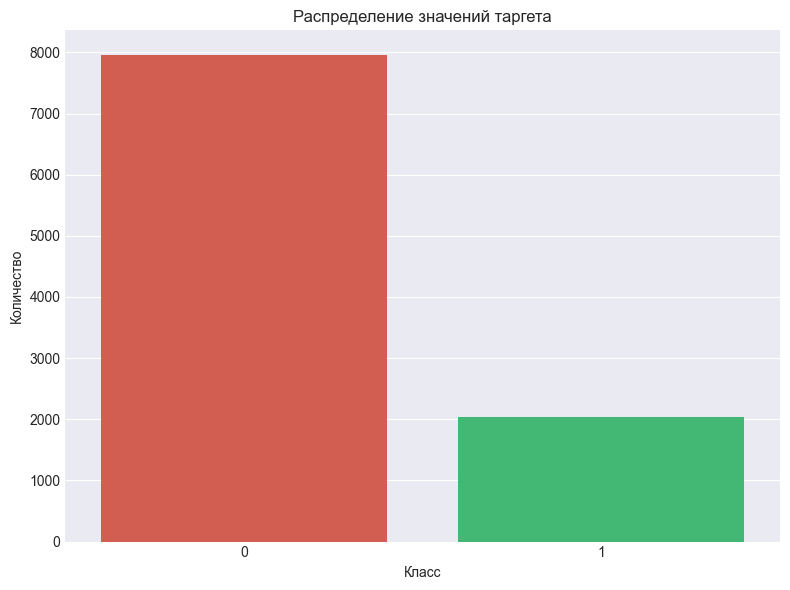

Оставшиеся клиенты (0): количество = 7963, процент = 79.63%
Ушедшие клиенты (1): количество = 2037, процент = 20.37%
Коэффициент дисбаланса (0 / 1): 3.91


In [63]:
plt.figure(figsize=(8, 6))
sns.countplot(data=raw_data, x='Exited', palette=['#e74c3c', '#2ecc71'])
plt.title('Распределение значений таргета')
plt.xlabel('Класс')
plt.ylabel('Количество')
plt.tight_layout()
plt.legend()
plt.show()

exit_count = raw_data['Exited'].value_counts()
exit_percentage = np.round(raw_data['Exited'].value_counts(normalize=True) * 100, 3)
imbalance_ratio = round(exit_count[0] / exit_count[1], 2)

print(f'Оставшиеся клиенты (0): количество = {exit_count.loc[0]}, процент = {exit_percentage.loc[0]}%')
print(f'Ушедшие клиенты (1): количество = {exit_count.loc[1]}, процент = {exit_percentage.loc[1]}%')
print(f'Коэффициент дисбаланса (0 / 1): {imbalance_ratio}')

Так как дисбалнс классов умеренный, то для работы с ним будем использовать параметр class_weight при обучении моделей и целевой метрикой будет PR-AUC

Далее посмотрим на распределение признаков в выборке и проверим данные на аномалии и выбросы

In [64]:
num_cols = list(raw_data.select_dtypes(include=['int64', 'float64']).columns)
num_cols.remove('Exited')
cat_cols = list(raw_data.select_dtypes(include=['object']).columns)
print(num_cols)

['RowNumber', 'CustomerId', 'CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary']


In [65]:
def num_ditribution(data, xcols, titles, xlables, figsize):
    fig, axs = plt.subplots(len(xcols), 2, figsize=figsize)
    for i in range(len(xcols)):
        sns.histplot(data=data, x=xcols[i], bins=30, ax=axs[i, 0])
        axs[i, 0].set_xlabel(xlables[i])
        axs[i, 0].set_ylabel('Количество')
        axs[i, 0].set_title(titles[i])

        sns.boxplot(x=data[xcols[i]], orient='h', ax=axs[i, 1])
        axs[i, 1].set_xlabel(xlables[i])
        axs[i, 1].set_title(titles[i])

    plt.subplots_adjust(wspace=0.3, hspace=0.9)
    plt.show()

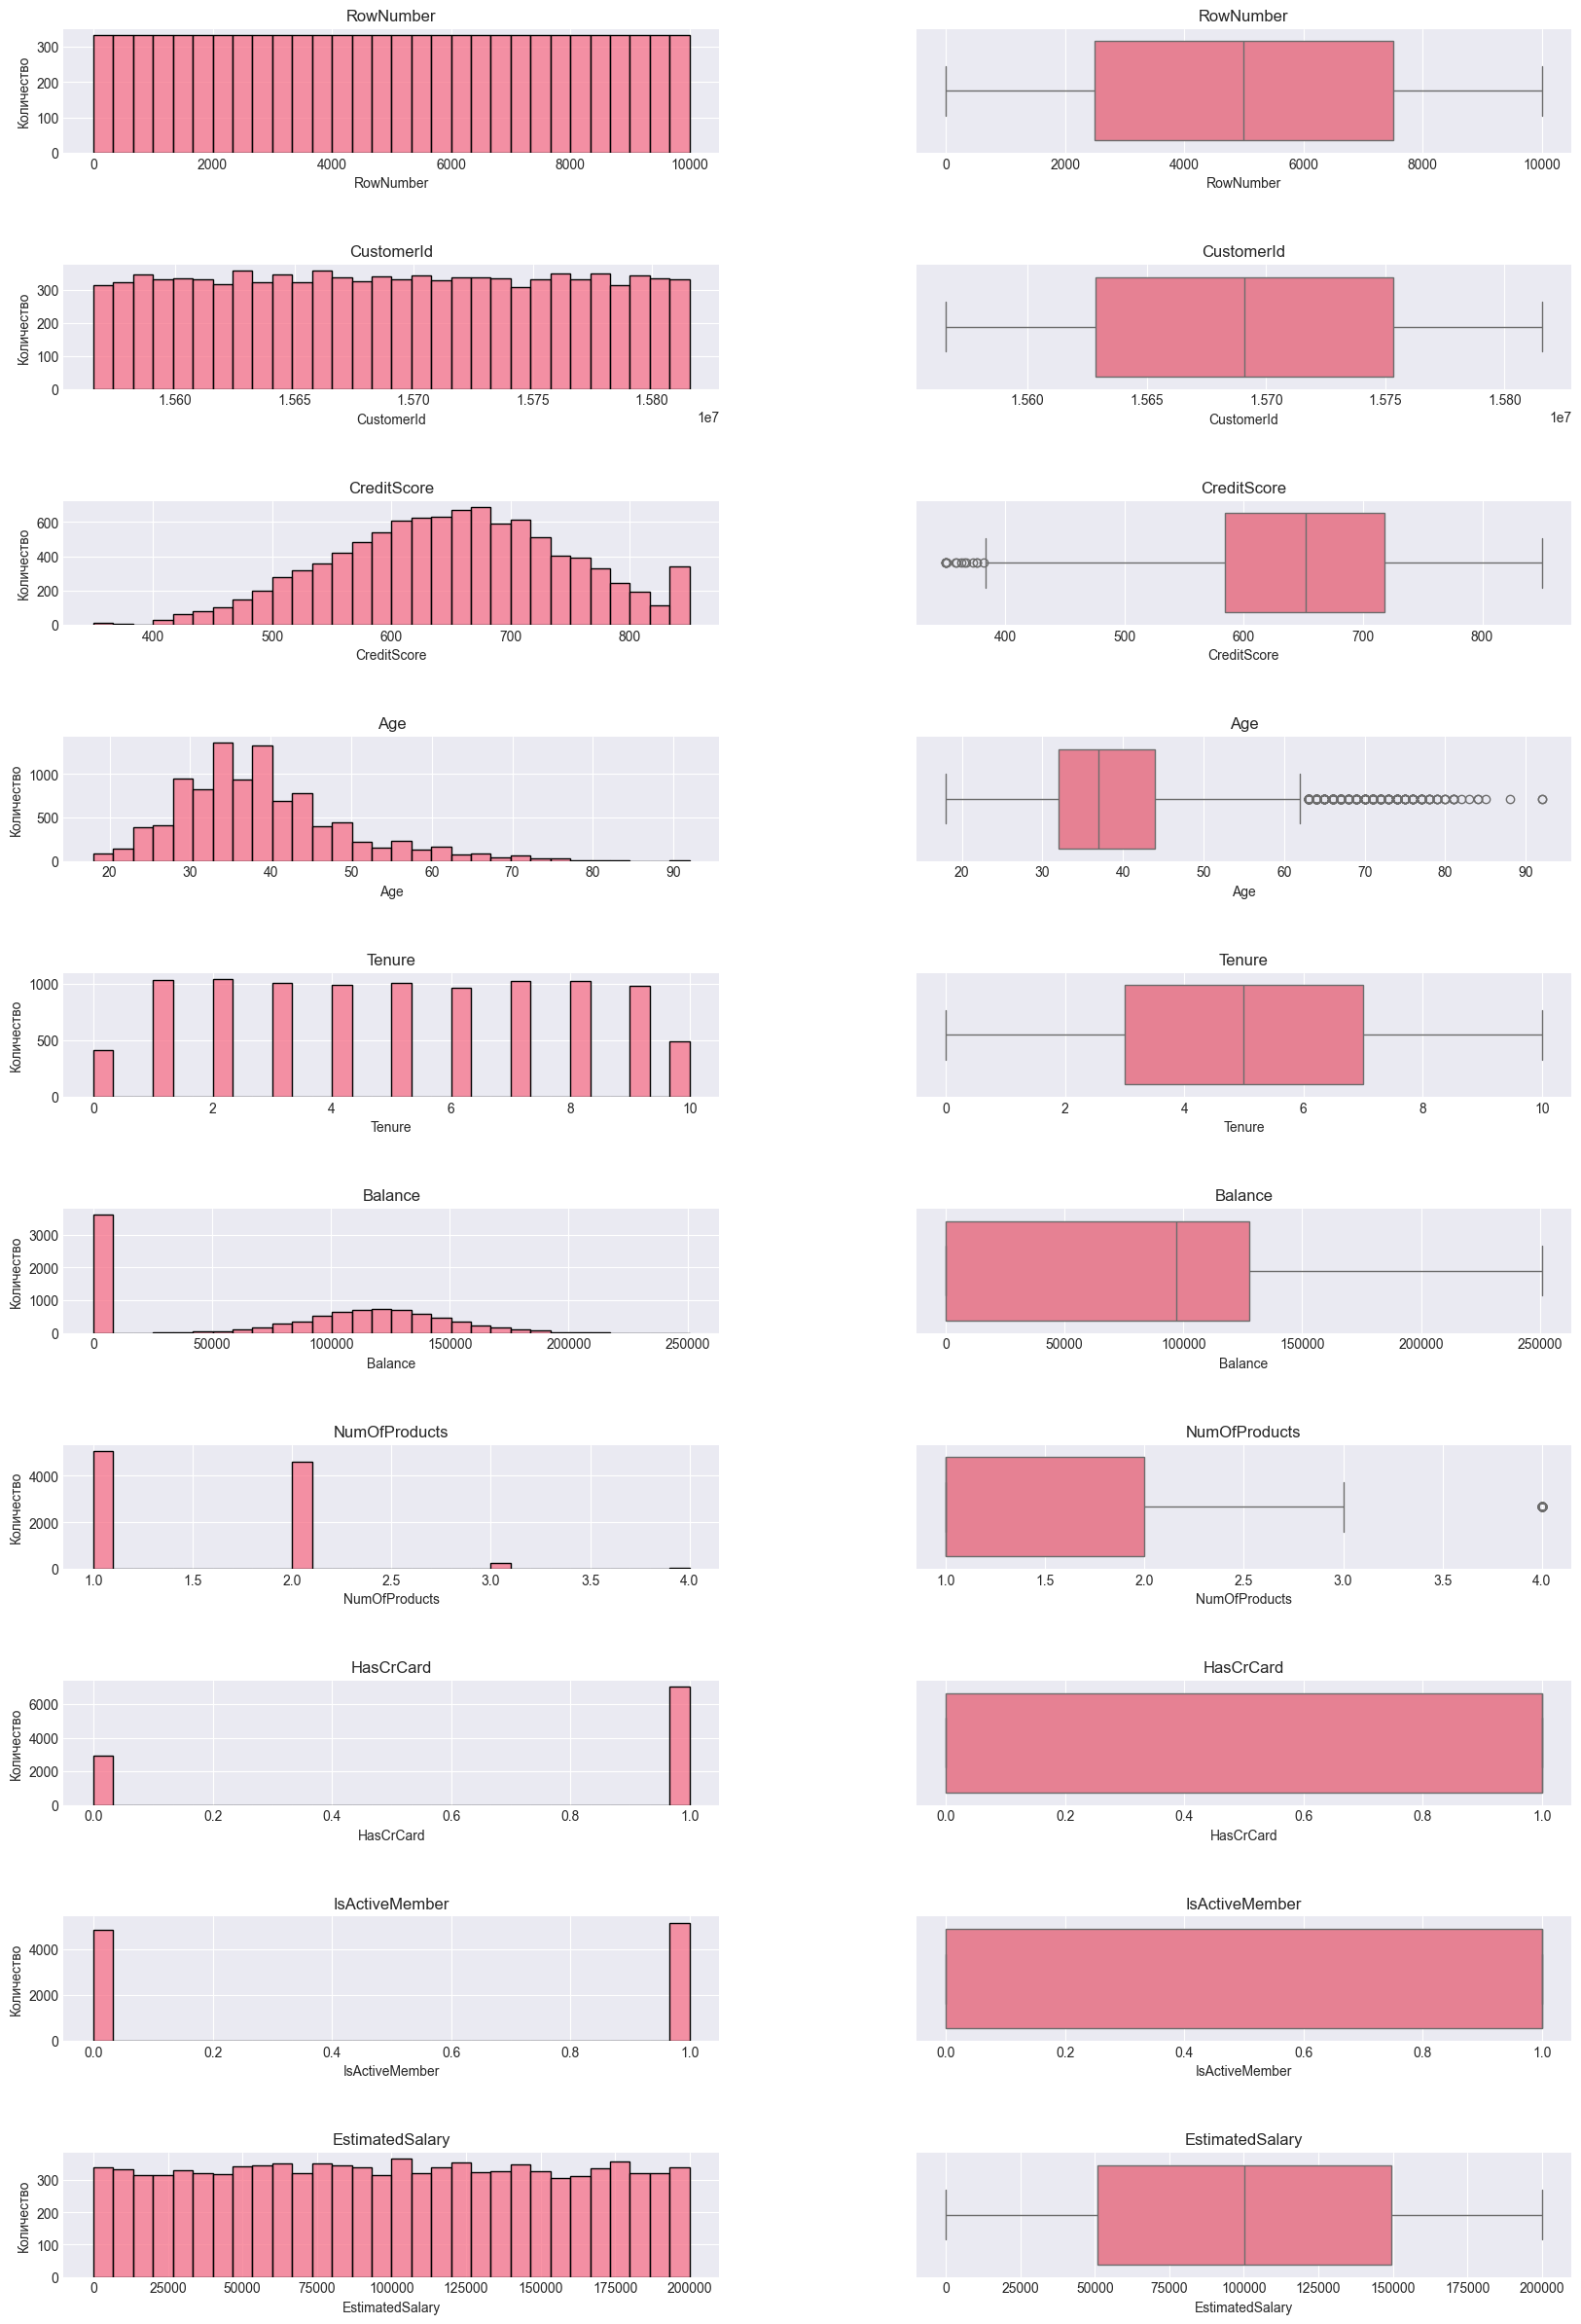

In [66]:
xcols = titles =  xlables = num_cols
num_ditribution(data=raw_data, xcols=xcols, titles=titles, xlables=xlables, figsize=(20, 30))

In [67]:
raw_data = raw_data[(raw_data['Age'] <= 65)]

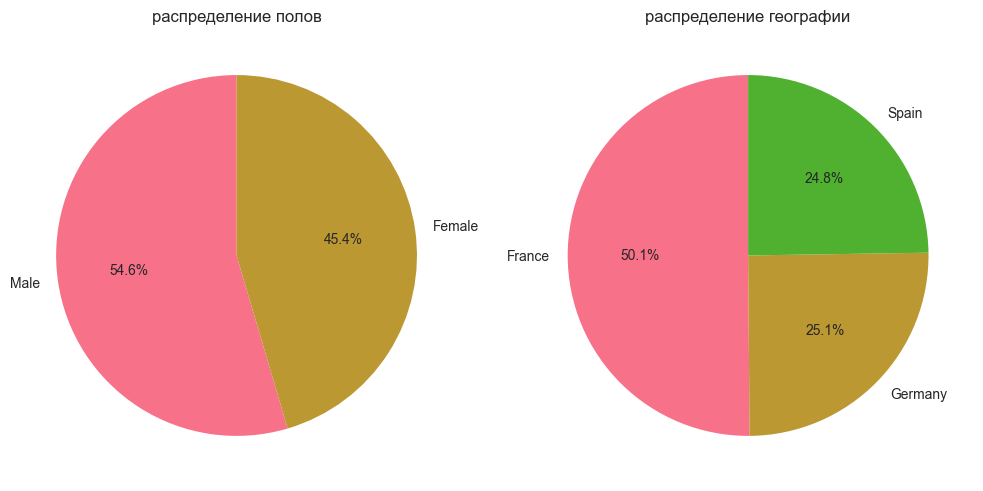

In [68]:

gender_counts = raw_data['Gender'].value_counts()
geography_count = raw_data['Geography'].value_counts()
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10, 5))

axes[0].pie(gender_counts, labels=gender_counts.index, startangle=90, autopct='%1.1f%%')
axes[0].set_title('распределение полов')

axes[1].pie(geography_count, labels=geography_count.index, startangle=90, autopct='%1.1f%%')
axes[1].set_title('распределение географии')

plt.tight_layout()
plt.show()

Проверим данные на наличие дубликатов

In [69]:
print(raw_data.isna().sum() / len(raw_data))

RowNumber          0.0
CustomerId         0.0
Surname            0.0
CreditScore        0.0
Geography          0.0
Gender             0.0
Age                0.0
Tenure             0.0
Balance            0.0
NumOfProducts      0.0
HasCrCard          0.0
IsActiveMember     0.0
EstimatedSalary    0.0
Exited             0.0
dtype: float64


в данных нет пропусков
  
теперь проверим данные на наличие дубликатов

In [70]:
print(raw_data.duplicated().sum())

0


В данных нет явных дубликатов 
  
Проверим данные на наличие неявных дубликатов

In [71]:
for col in raw_data.select_dtypes(include=['object']):
    print(f' {col}: {raw_data[col].unique()}\n')

 Surname: ['Hargrave' 'Hill' 'Onio' ... 'Kashiwagi' 'Aldridge' 'Burbidge']

 Geography: ['France' 'Spain' 'Germany']

 Gender: ['Female' 'Male']



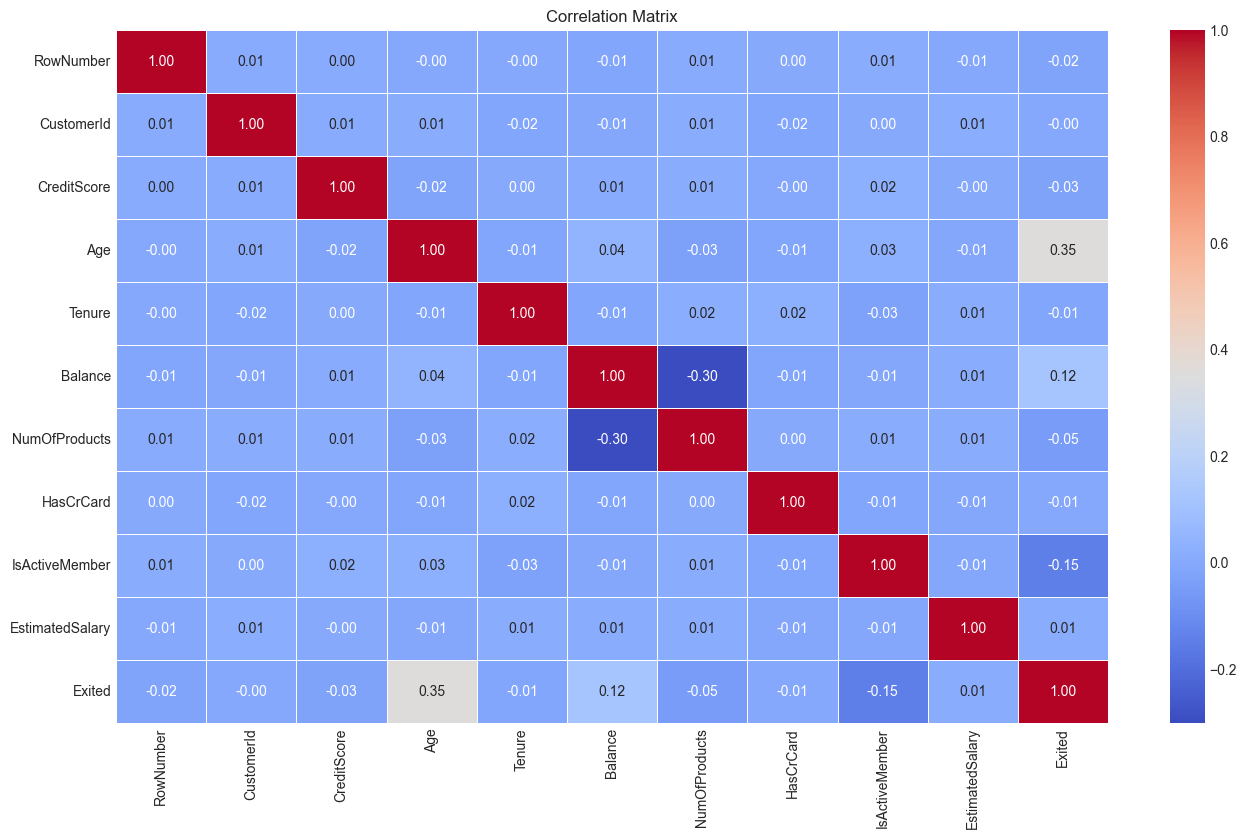

In [72]:
corr_matrix = raw_data.corr(numeric_only=True, method='pearson')
plt.figure(figsize=(16, 9))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

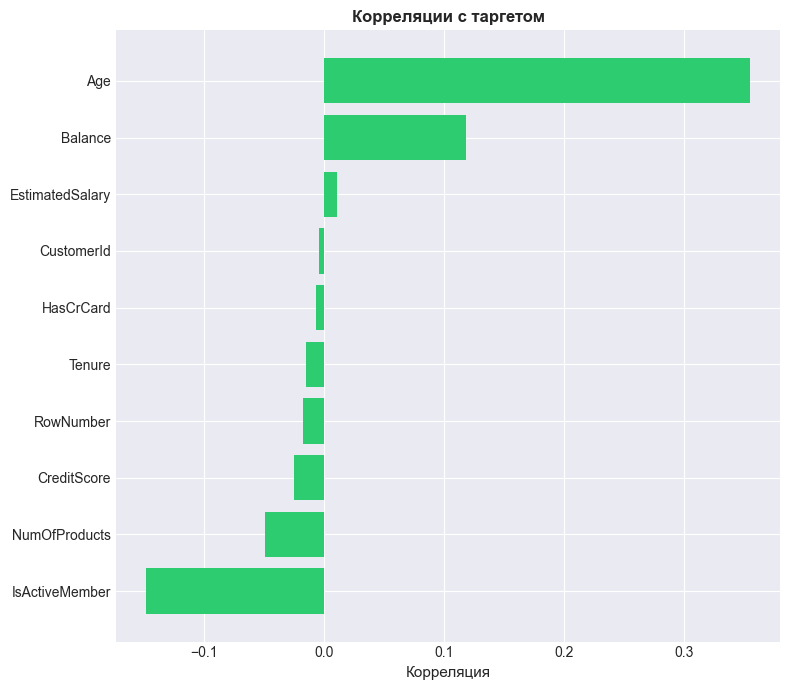

In [73]:
correlations = raw_data.corr(numeric_only=True)['Exited'].drop('Exited').sort_values(ascending=True)
plt.figure(figsize=(8, 7))
plt.barh(correlations.index, correlations.values, color='#2ecc71')
plt.title('Корреляции с таргетом', fontsize=12, fontweight='bold')
plt.xlabel('Корреляция', fontsize=11)
plt.tight_layout()
plt.show()

In [74]:
raw_data.drop(columns=['RowNumber', 'CustomerId'], inplace=True, axis=1)
clean_data = raw_data
clean_data = clean_data.reset_index(drop=True)

Выбор и обучение моделей

In [75]:
mlflow.set_experiment('Churn prediction | baseline')
X = clean_data.drop('Exited', axis=1)
y = clean_data['Exited']


num_cols = [x for x in X.select_dtypes(include=['int64', 'float64']).columns]
cat_features = [x for x in X.select_dtypes(include=['object']).columns]
ohe_cols = ['Surname']
ord_cols = ['Geography', 'Gender']

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)


2026/02/22 18:36:25 INFO mlflow.tracking.fluent: Experiment with name 'Churn prediction | baseline' does not exist. Creating a new experiment.


In [76]:
num_pipe = Pipeline([
    ('imputer', SimpleImputer(missing_values=np.nan, strategy='median')),
    ('min_max_scaler', MinMaxScaler())
])

ordinal_pipe = Pipeline([
    ('impute_before_ord', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
    ('ord', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)),
])

ohe_pipe = Pipeline([
    ('impute', SimpleImputer(missing_values=np.nan, strategy='most_frequent')),
    ('ohe', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'))
])

data_preprocessor = ColumnTransformer([
    ('num', num_pipe, num_cols),
    ('ohe', ohe_pipe, ohe_cols),
    ('ordinal', ordinal_pipe, ord_cols)    
], remainder='passthrough')

2026/02/22 18:36:38 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


roc-auc: 0.746
roc-prc: 0.472
F1-score: 0.473
🏃 View run Baseline | log_reg at: http://localhost:5000/#/experiments/2/runs/b06d12239ca54f48a33670325cce483c
🧪 View experiment at: http://localhost:5000/#/experiments/2


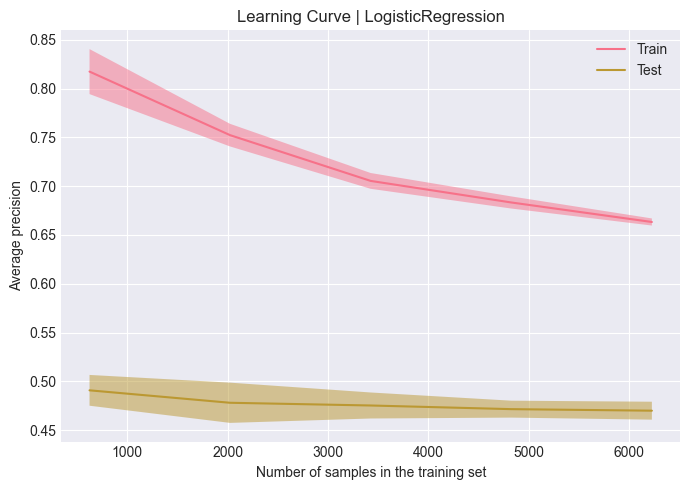

In [77]:
with mlflow.start_run(run_name='Baseline | log_reg'):
    log_reg_pipe = Pipeline([
        ('data_preprocessor', data_preprocessor),
        ('log_reg', LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced', max_iter=1000))
    ])

    l_start = time.time()
    log_reg_pipe.fit(X_train, y_train)
    l_end = time.time()

    p_start = time.time()
    y_pred = log_reg_pipe.predict(X_test)
    y_pred_proba = log_reg_pipe.predict_proba(X_test)[:, 1]
    p_end = time.time()

    roc_auc = round(roc_auc_score(y_test, y_pred_proba),3)
    roc_prc = round(average_precision_score(y_test, y_pred_proba), 3)
    f1 = round(f1_score(y_test, y_pred),3)

    fig, ax = plt.subplots(figsize=(7, 5))
    LearningCurveDisplay.from_estimator(
        log_reg_pipe,
        X_train,
        y_train,
        cv=cv,
        scoring='average_precision',
        n_jobs=-1,
        ax=ax
    )

    ax.set_title('Learning Curve | LogisticRegression')
    fig.tight_layout()
    fig.show()

    Path("plots").mkdir(parents=True, exist_ok=True)
    try:
        mlflow.log_figure(fig, "plots/learning_curve_log_reg.png")
    except Exception as e:
        print(f"Warning: Could not log figure to MLflow: {e}")
        fig.savefig("plots/learning_curve_log_reg.png", dpi=100, bbox_inches='tight')

    mlflow.log_params({
    "model": "LogisticRegression",
    "class_weight": "balanced",
    "max_iter": 1000
    })
    
    mlflow.log_metrics({
        'learning_time': l_end - l_start,
        'prediction_time': p_end - p_start,
        'roc_auc': roc_auc,
        'roc_prc': roc_prc,
        'f1': f1
    })

    mlflow.sklearn.log_model(log_reg_pipe, artifact_path="model")

    print(f'roc-auc: {roc_auc}\nroc-prc: {roc_prc}\nF1-score: {f1}')

2026/02/22 19:20:35 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


roc-auc: 0.71
roc-prc: 0.383
F1-score: 0.538
🏃 View run Baseline | Dtree at: http://localhost:5000/#/experiments/2/runs/c35dbd48fabc413192e1708f4e668a53
🧪 View experiment at: http://localhost:5000/#/experiments/2


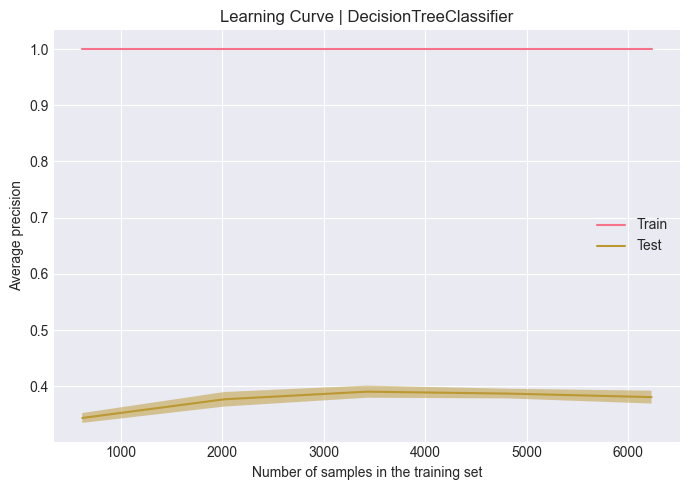

In [80]:
with mlflow.start_run(run_name='Baseline | Dtree'):
    dtree_pipe = Pipeline([
        ('data_preprocessor', data_preprocessor),
        ('dtree', DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'))
    ])

    l_start = time.time()
    dtree_pipe.fit(X_train, y_train)
    l_end = time.time()

    p_start = time.time()
    y_pred = dtree_pipe.predict(X_test)
    y_pred_proba = dtree_pipe.predict_proba(X_test)[:, 1]
    p_end = time.time()

    roc_auc = round(roc_auc_score(y_test, y_pred_proba),3)
    roc_prc = round(average_precision_score(y_test, y_pred_proba), 3)
    f1 = round(f1_score(y_test, y_pred),3)

    fig, ax = plt.subplots(figsize=(7, 5))
    LearningCurveDisplay.from_estimator(
        estimator= dtree_pipe,
        X= X_train,
        y=y_train,
        cv=cv,
        scoring='average_precision',
        n_jobs=-1,
        ax=ax
    )
    
    ax.set_title('Learning Curve | DecisionTreeClassifier')
    fig.tight_layout()
    fig.show()
    
    try:
        mlflow.log_figure(fig, "plots/learning_curve_dtree.png")
    except Exception as e:
        print(f"Warning: Could not log figure to MLflow: {e}")
        fig.savefig("plots/learning_curve_dtree.png", dpi=100, bbox_inches='tight')
    
    mlflow.log_metrics({
        'learning_time': round(l_end - l_start, 3),
        'prediction_time': round(p_end - p_start, 3),
        'roc_auc': roc_auc,
        'roc_prc': roc_prc,
        'f1': f1
    })

    mlflow.log_params({
    "model": "DecisionTreeClassifier",
    "class_weight": "balanced",
    })

    mlflow.sklearn.log_model(dtree_pipe, artifact_path="model")

    print(f'roc-auc: {roc_auc}\nroc-prc: {roc_prc}\nF1-score: {f1}')

2026/02/22 19:36:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


roc-auc: 0.844
roc-prc: 0.665
F1-score: 0.509
🏃 View run Baseline | RandomForest at: http://localhost:5000/#/experiments/2/runs/59ebc5a835ff44a996eb2f880fa7794a
🧪 View experiment at: http://localhost:5000/#/experiments/2


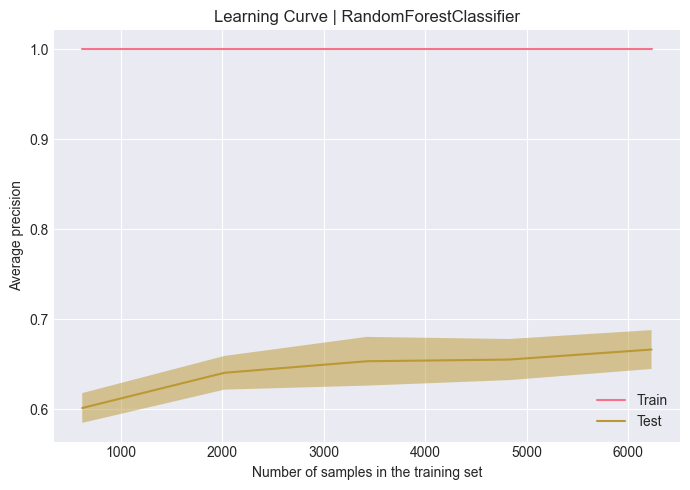

In [84]:
with mlflow.start_run(run_name="Baseline | RandomForest"):
    rf_pipe = Pipeline([
        ("data_preprocessor", data_preprocessor),
        ('rf', RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'))
    ])

    l_start = time.time()
    rf_pipe.fit(X_train, y_train)
    l_end = time.time()

    p_start = time.time()
    y_pred = rf_pipe.predict(X_test)
    y_pred_proba = rf_pipe.predict_proba(X_test)[:, 1]
    p_end = time.time()

    roc_auc = round(roc_auc_score(y_test, y_pred_proba),3)
    roc_prc = round(average_precision_score(y_test, y_pred_proba), 3)
    f1 = round(f1_score(y_test, y_pred),3)

    fig, ax = plt.subplots(figsize=(7, 5))
    LearningCurveDisplay.from_estimator(
        estimator=rf_pipe,
        X=X_train,
        y=y_train,
        cv=cv,
        scoring='average_precision',
        n_jobs=-1,
        ax=ax
    )

    ax.set_title('Learning Curve | RandomForestClassifier')
    fig.tight_layout()
    fig.show()

    try:
        mlflow.log_figure(fig, "plots/learning_curve_ка.png")
    except Exception as e:
        print(f"Warning: Could not log figure to MLflow: {e}")
        fig.savefig("plots/learning_curve_rf.png", dpi=100, bbox_inches='tight')

    mlflow.log_params({
        'model': 'RandomForestClassifier',
        "class_weight": "balanced",
    })

    mlflow.log_metrics({
        'learning_time': round(l_end - l_start, 3),
        'prediction_time': round(p_end - p_start, 3),
        'roc_auc': roc_auc,
        'roc_prc': roc_prc,
        'f1': f1
    })

    mlflow.sklearn.log_model(rf_pipe, artifact_path="model")

    print(f'roc-auc: {roc_auc}\nroc-prc: {roc_prc}\nF1-score: {f1}')